In [1]:
import os
import numpy as np
import csv
import json
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from functools import partial
from matplotlib import ticker

fm.fontManager.addfont('metric_data/xkcd.ttf')
import logging
logging.getLogger('matplotlib.font_manager').disabled = True
from matplotlib_venn import venn2


In [2]:
cset_colors = np.array(["#0B1F41","#003DA6","#B53A6D","#7AC4A5","#F17F4C","#15AFD0","#839DC5"])

In [3]:
## loading CLUSTER MODULARITY by citations
cluster_modularity = []
with open('metric_data/cluster_modularity_comparison_by_citations.csv') as csvfile:
    spamreader = csv.reader(csvfile)
    for row in spamreader:
        cluster_modularity.append(row)
cluster_modularity = np.array(cluster_modularity)
cluster_modularity[cluster_modularity == ''] = '0'
[modularity, old_cluster_modularity, new_cluster_modularity] = cluster_modularity.T[:,1:].astype(float)

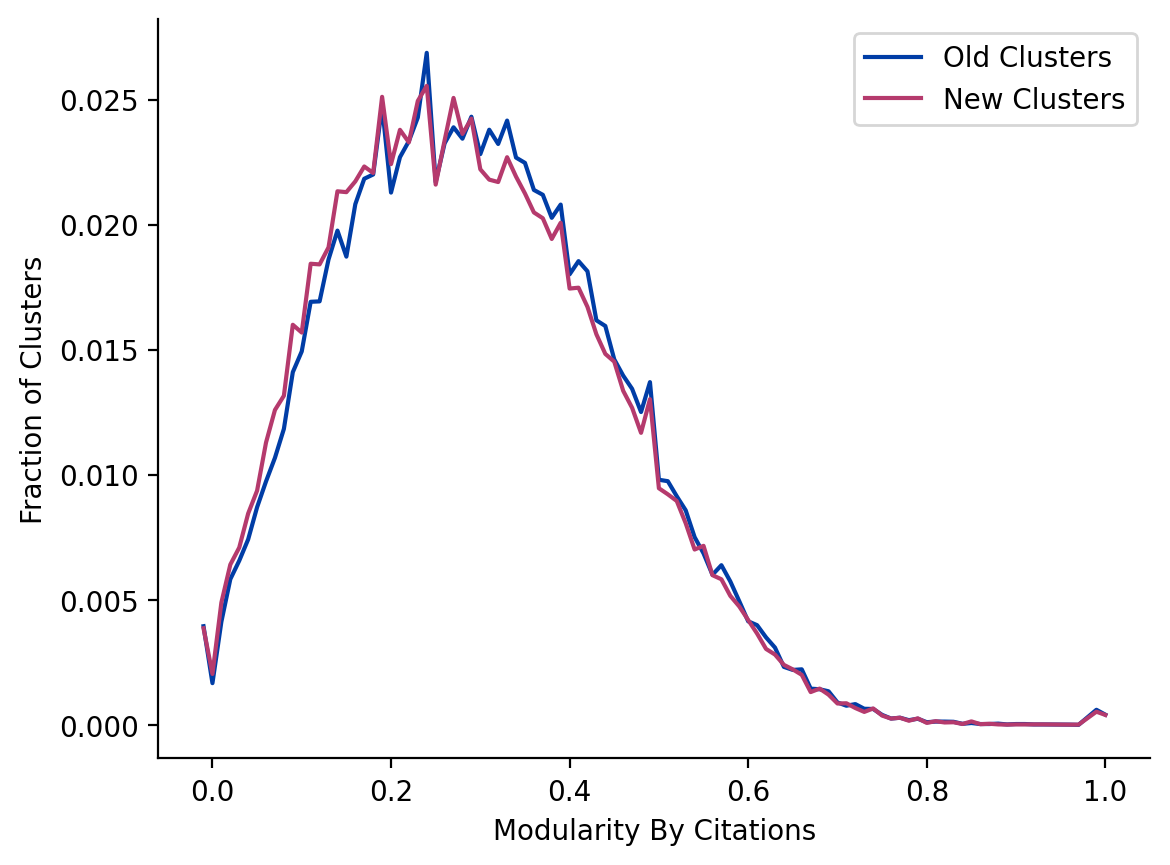

In [4]:
# with plt.xkcd():
plt.figure(dpi=200)
ax = plt.subplot(111)
ax.spines[['top','right']].set_visible(False)
plt.plot(modularity, old_cluster_modularity/sum(old_cluster_modularity),
        c=cset_colors[1],label = 'Old Clusters')
plt.plot(modularity, new_cluster_modularity/sum(new_cluster_modularity),
        c=cset_colors[2],label = 'New Clusters')
plt.ylabel('Fraction of Clusters')
plt.xlabel('Modularity By Citations')
plt.legend()
plt.show()

In [77]:
cluster_level_distribution = []
with open('metric_data/cluster_assignment_level_distribution_comparison.csv') as csvfile:
    spamreader = csv.reader(csvfile)
    for row in spamreader:
        cluster_level_distribution.append(row)
cluster_level_distribution = np.array(cluster_level_distribution)
cluster_level_distribution[cluster_level_distribution == ''] = '0'
[cluster_levels, old_cluster_level_distribution,
 new_cluster_level_distribution] = cluster_level_distribution.T[:,1:].astype(float)

In [80]:
patent_assignment_level_distribution = []
with open('metric_data/patent_assignment_level_distribution_comparison.csv') as csvfile:
    spamreader = csv.reader(csvfile)
    for row in spamreader:
        patent_assignment_level_distribution.append(row)
patent_assignment_level_distribution = np.array(patent_assignment_level_distribution)
[levels, 
 old_patent_assignment_level_distribution, new_patent_assignment_level_distribution] = patent_assignment_level_distribution.T[:,1:].astype(float)

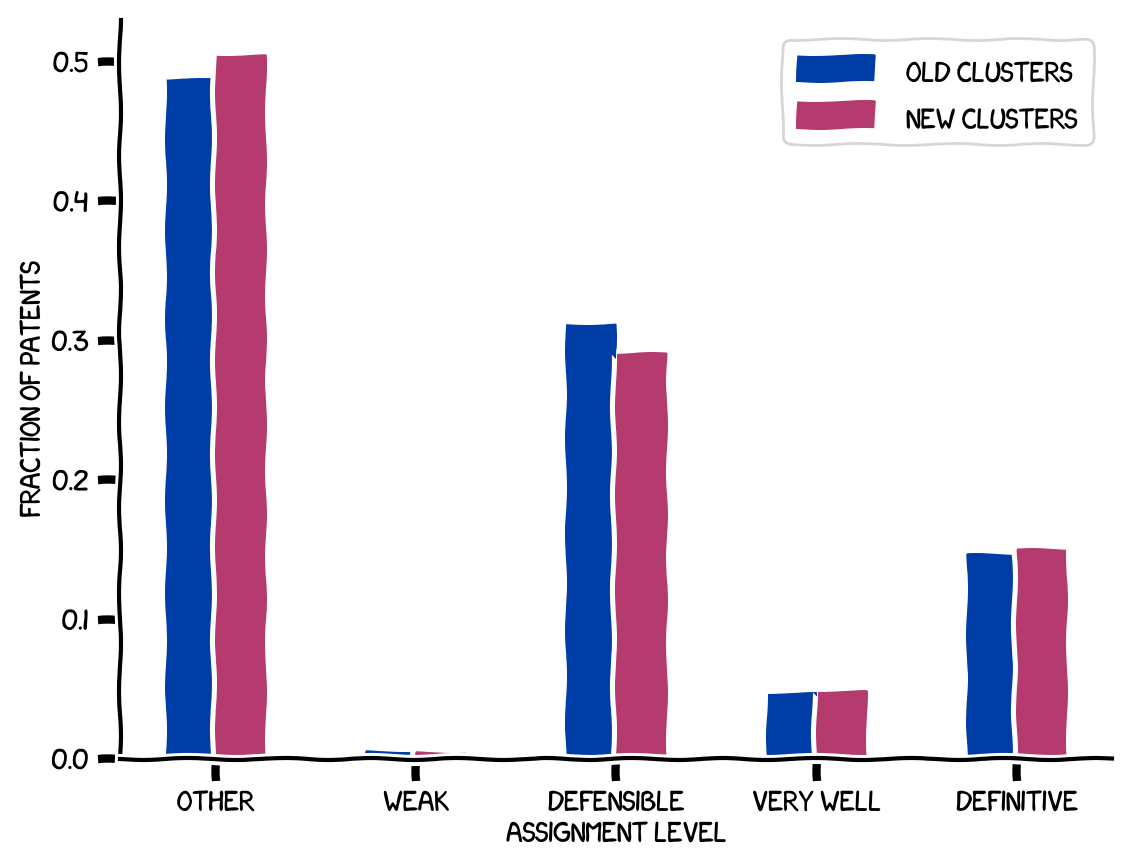

In [81]:
with plt.xkcd():
    plt.figure(dpi=200)
    ax = plt.subplot(111)
    ax.spines[['top','right']].set_visible(False)
    plt.bar(levels-0.25/2, 
            old_patent_assignment_level_distribution/sum(old_patent_assignment_level_distribution), 
            width = 0.25,
            color = cset_colors[1], label='Old Clusters')
    plt.bar(levels+0.25/2, 
            new_patent_assignment_level_distribution/sum(new_patent_assignment_level_distribution), 
            width = 0.25,
            color = cset_colors[2], label='New Clusters')
    plt.legend()
    plt.xticks([0,1,2,3,4])
    ax.set_xticklabels(['Other','Weak','Defensible','Very Well','Definitive'])
    plt.ylabel('Fraction of Patents')
    plt.xlabel('Assignment Level')
    plt.show()

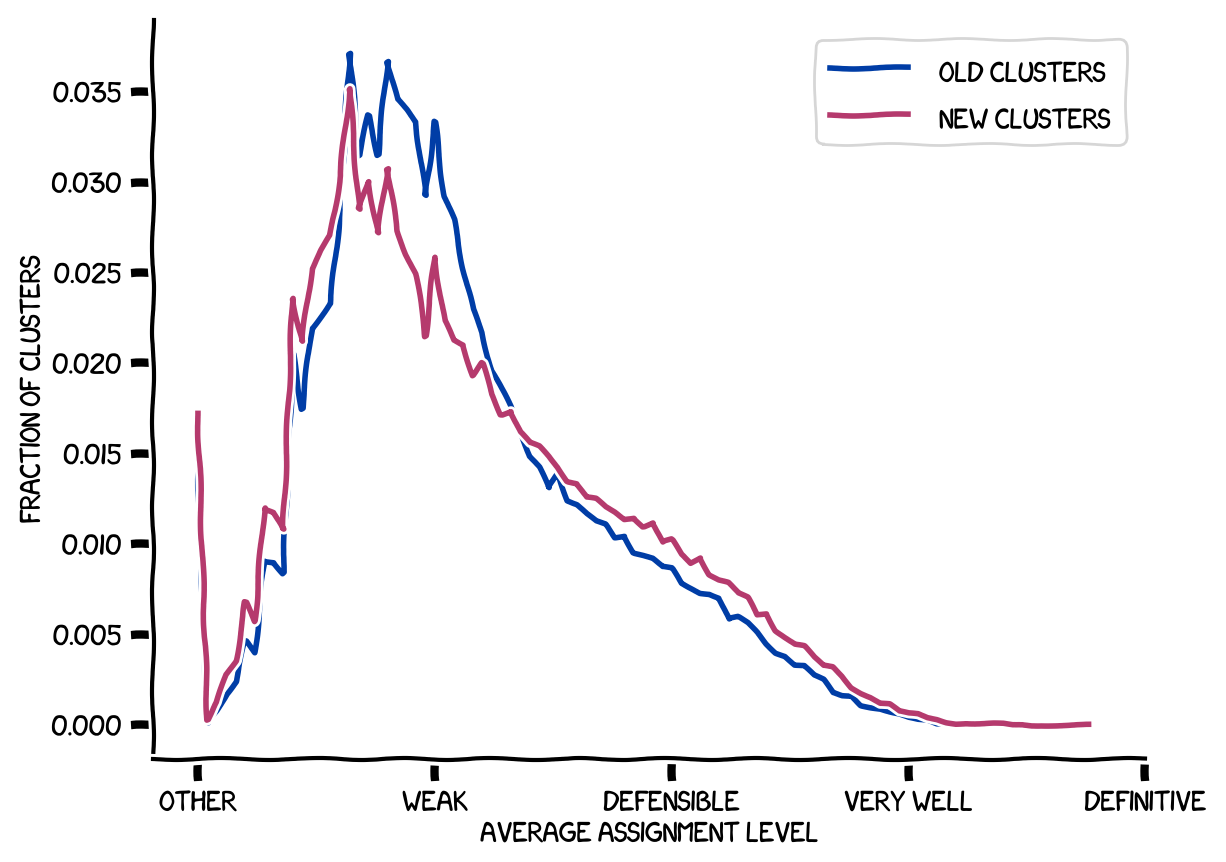

In [79]:
with plt.xkcd():
    plt.figure(dpi=200)
    ax = plt.subplot(111)
    ax.spines[['top','right']].set_visible(False)
    plt.plot(cluster_levels,
             old_cluster_level_distribution/sum(old_cluster_level_distribution), 
             c=cset_colors[1],label='Old Clusters')
    plt.plot(cluster_levels,
             new_cluster_level_distribution/sum(new_cluster_level_distribution), 
             c=cset_colors[2],label='New Clusters')
    plt.ylabel('Fraction of Clusters')
    plt.xlabel('Average Assignment Level')
    plt.xticks([0,1,2,3,4])
    ax.set_xticklabels(['Other','Weak','Defensible','Very Well','Definitive'])
    plt.legend()
    plt.show()

In [24]:
cluster_links_fractions = []
with open('metric_data/cluster_links_fractions_comparison_by_citations.csv') as csvfile:
    spamreader = csv.reader(csvfile)
    for row in spamreader:
        cluster_links_fractions.append(row)
cluster_links_fractions = np.array(cluster_links_fractions)
cluster_links_fractions[cluster_links_fractions == ''] = '0'
[cluster_links_fractions, old_cluster_links_fractions_counts,
new_cluster_links_fractions_counts] = cluster_links_fractions.T[:,1:].astype(float)

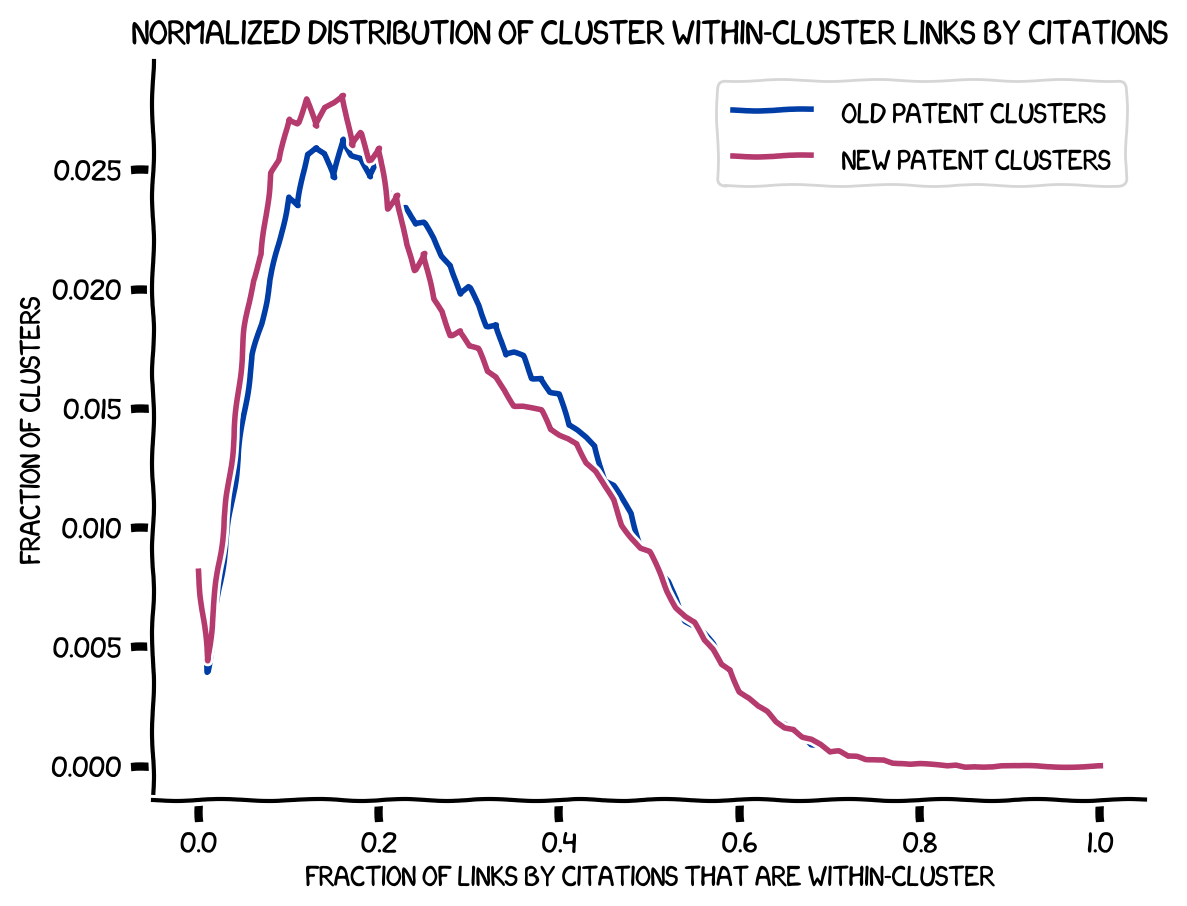

In [25]:
with plt.xkcd():
    plt.figure(dpi=200)
    ax = plt.subplot(111)
    ax.spines[['top','right']].set_visible(False)
    plt.plot(cluster_links_fractions, old_cluster_links_fractions_counts/sum(old_cluster_links_fractions_counts),
            c=cset_colors[1], label='Old Patent Clusters')
    plt.plot(cluster_links_fractions, new_cluster_links_fractions_counts/sum(new_cluster_links_fractions_counts),
            c=cset_colors[2], label='New Patent Clusters')
    plt.legend()
    plt.ylabel('Fraction of Clusters')
    plt.xlabel('Fraction of Links by Citations that are Within-Cluster')
    plt.title('Normalized Distribution of Cluster Within-Cluster Links by Citations')
    plt.show()

In [12]:
## loading CLUSTER MODULARITY by weights instead of citations
cluster_modularity_by_weights = []
with open('metric_data/cluster_modularity_comparison_by_weights.csv') as csvfile:
    spamreader = csv.reader(csvfile)
    for row in spamreader:
        cluster_modularity_by_weights.append(row)
cluster_modularity_by_weights = np.array(cluster_modularity_by_weights)
cluster_modularity_by_weights[cluster_modularity_by_weights == ''] = '0'
[modularity_by_weights, old_cluster_modularity_by_weights, new_cluster_modularity_by_weights] = cluster_modularity_by_weights.T[:,1:].astype(float)

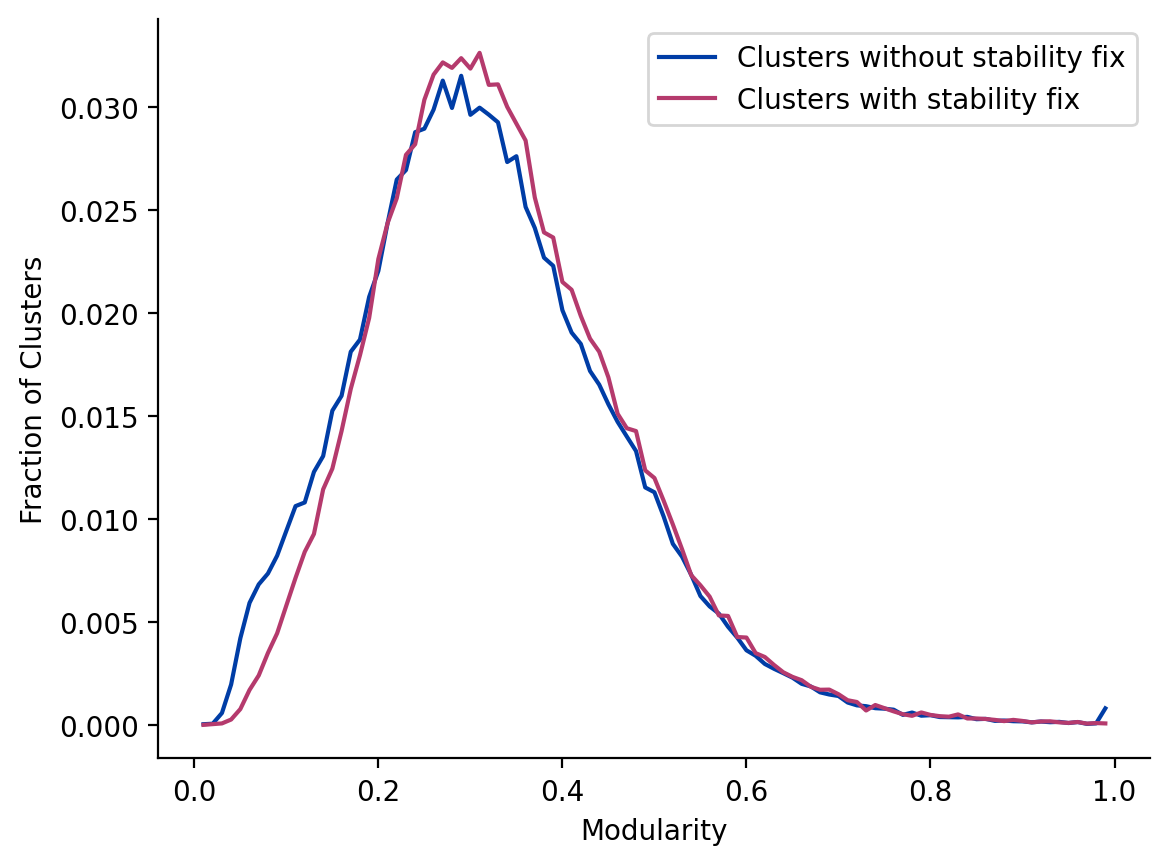

In [13]:
# with plt.xkcd():
plt.figure(dpi=200)
ax = plt.subplot(111)
ax.spines[['top','right']].set_visible(False)
plt.plot(modularity_by_weights, old_cluster_modularity_by_weights/sum(old_cluster_modularity_by_weights),
        c=cset_colors[1],label = 'Clusters without stability fix')
plt.plot(modularity_by_weights, new_cluster_modularity_by_weights/sum(new_cluster_modularity_by_weights),
        c=cset_colors[2],label = 'Clusters with stability fix')
plt.ylabel('Fraction of Clusters')
plt.xlabel('Modularity')
plt.legend()
plt.show()

In [83]:
cluster_level_distribution_by_weights = []
with open('metric_data/cluster_assignment_level_distribution_comparison_by_weights.csv') as csvfile:
    spamreader = csv.reader(csvfile)
    for row in spamreader:
        cluster_level_distribution_by_weights.append(row)
cluster_level_distribution_by_weights = np.array(cluster_level_distribution_by_weights)
cluster_level_distribution_by_weights[cluster_level_distribution_by_weights == ''] = '0'
[cluster_levels_by_weights, old_cluster_level_distribution_by_weights,
 new_cluster_level_distribution_by_weights] = cluster_level_distribution_by_weights.T[:,1:].astype(float)

In [85]:
patent_assignment_level_distribution_by_weights = []
with open('metric_data/patent_assignment_level_distribution_comparison_by_weights.csv') as csvfile:
    spamreader = csv.reader(csvfile)
    for row in spamreader:
        patent_assignment_level_distribution_by_weights.append(row)
patent_assignment_level_distribution_by_weights = np.array(patent_assignment_level_distribution_by_weights)
[levels_by_weights, old_patent_assignment_level_distribution_by_weights,
 new_patent_assignment_level_distribution_by_weights] = patent_assignment_level_distribution_by_weights.T[:,1:].astype(float)

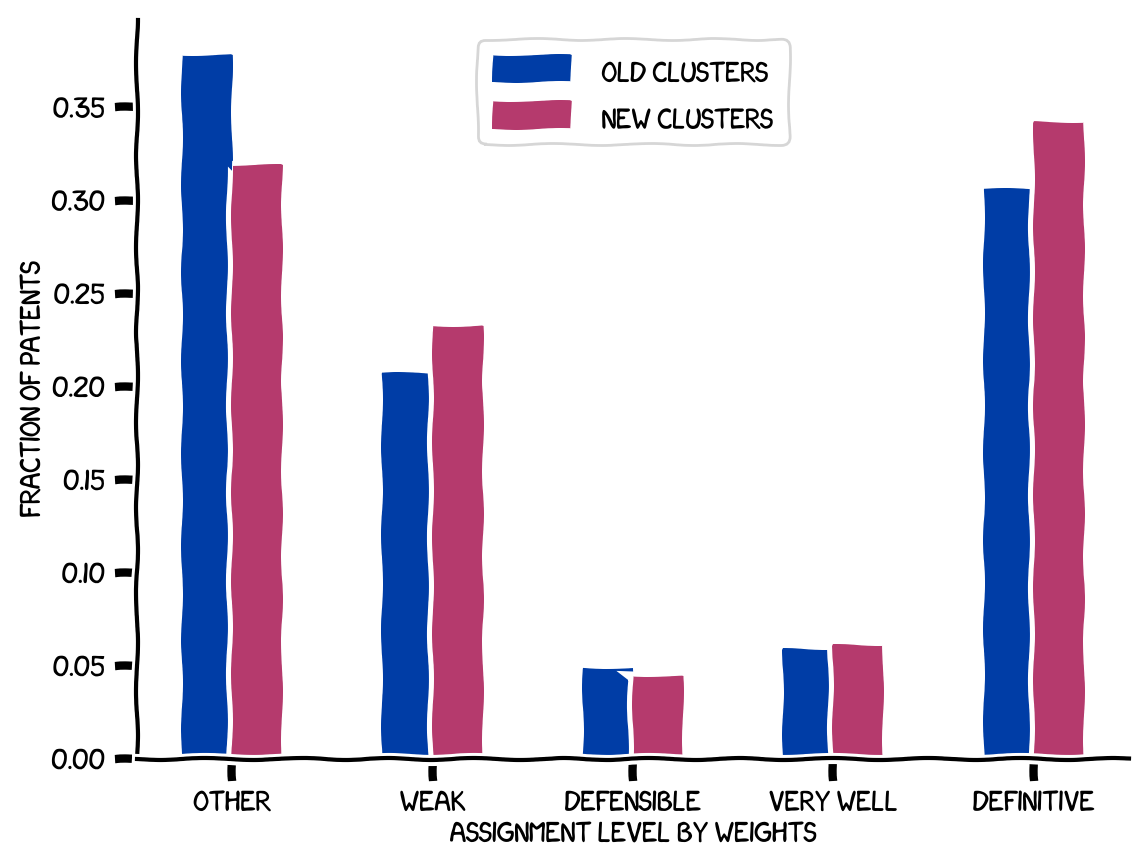

In [86]:
with plt.xkcd():
    plt.figure(dpi=200)
    ax = plt.subplot(111)
    ax.spines[['top','right']].set_visible(False)
    plt.bar(levels-0.25/2, 
            old_patent_assignment_level_distribution_by_weights/sum(old_patent_assignment_level_distribution_by_weights), 
            width = 0.25,
            color = cset_colors[1], label='Old Clusters')
    plt.bar(levels+0.25/2, 
            new_patent_assignment_level_distribution_by_weights/sum(new_patent_assignment_level_distribution_by_weights), 
            width = 0.25,
            color = cset_colors[2], label='New Clusters')
    plt.legend()
    plt.xticks([0,1,2,3,4])
    ax.set_xticklabels(['Other','Weak','Defensible','Very Well','Definitive'])
    plt.ylabel('Fraction of Patents')
    plt.xlabel('Assignment Level By Weights')
    plt.show()

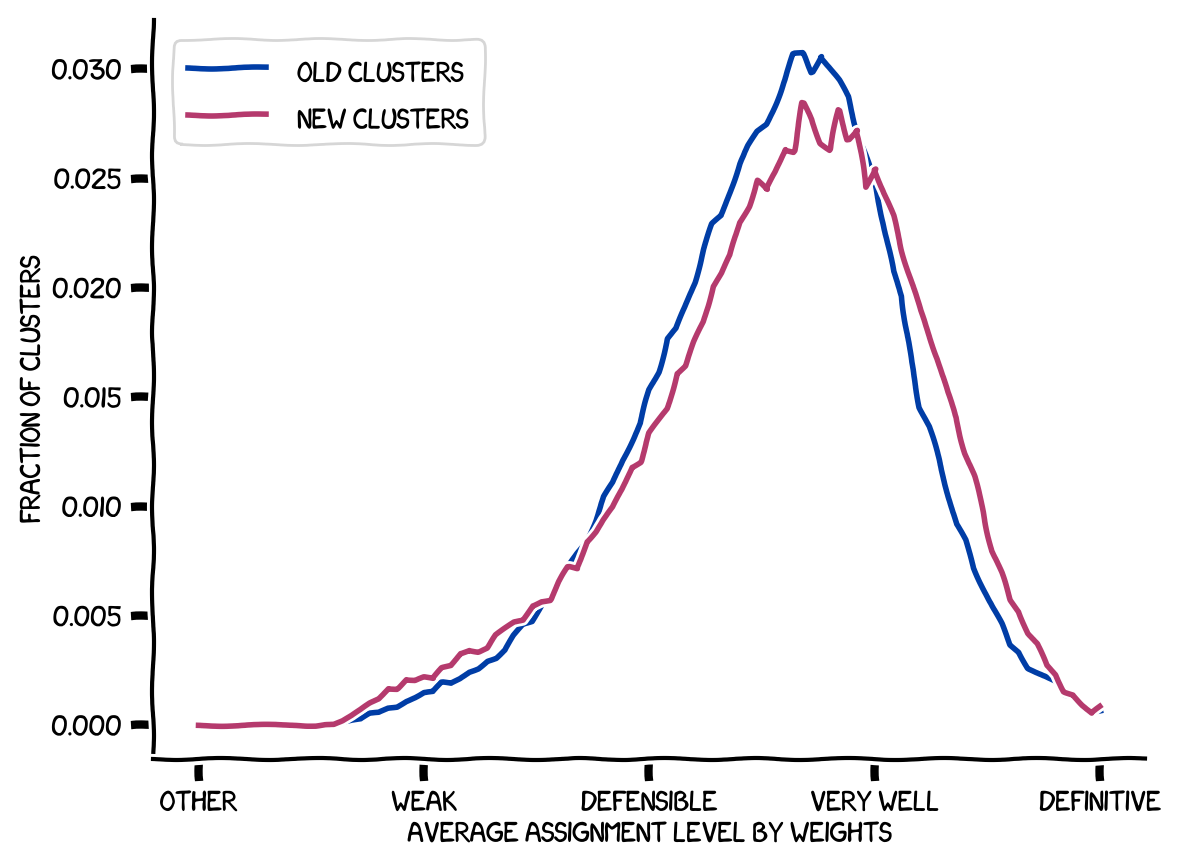

In [88]:
with plt.xkcd():
    plt.figure(dpi=200)
    ax = plt.subplot(111)
    ax.spines[['top','right']].set_visible(False)
    plt.plot(cluster_levels_by_weights,
             old_cluster_level_distribution_by_weights/sum(old_cluster_level_distribution_by_weights), 
             c=cset_colors[1],label='Old Clusters')
    plt.plot(cluster_levels_by_weights,
             new_cluster_level_distribution_by_weights/sum(new_cluster_level_distribution_by_weights), 
             c=cset_colors[2],label='New Clusters')
    plt.ylabel('Fraction of Clusters')
    plt.xlabel('Average Assignment Level By Weights')
    plt.xticks([0,1,2,3,4])
    ax.set_xticklabels(['Other','Weak','Defensible','Very Well','Definitive'])
    plt.legend()
    plt.show()

In [26]:
cluster_links_fractions_by_weights = []
with open('metric_data/cluster_links_fractions_comparison_by_weights.csv') as csvfile:
    spamreader = csv.reader(csvfile)
    for row in spamreader:
        cluster_links_fractions_by_weights.append(row)
cluster_links_fractions_by_weights = np.array(cluster_links_fractions_by_weights)
cluster_links_fractions_by_weights[cluster_links_fractions_by_weights == ''] = '0'
[cluster_links_fractions_by_weights, old_cluster_links_fractions_counts_by_weights,
new_cluster_links_fractions_counts_by_weights] = cluster_links_fractions_by_weights.T[:,1:].astype(float)

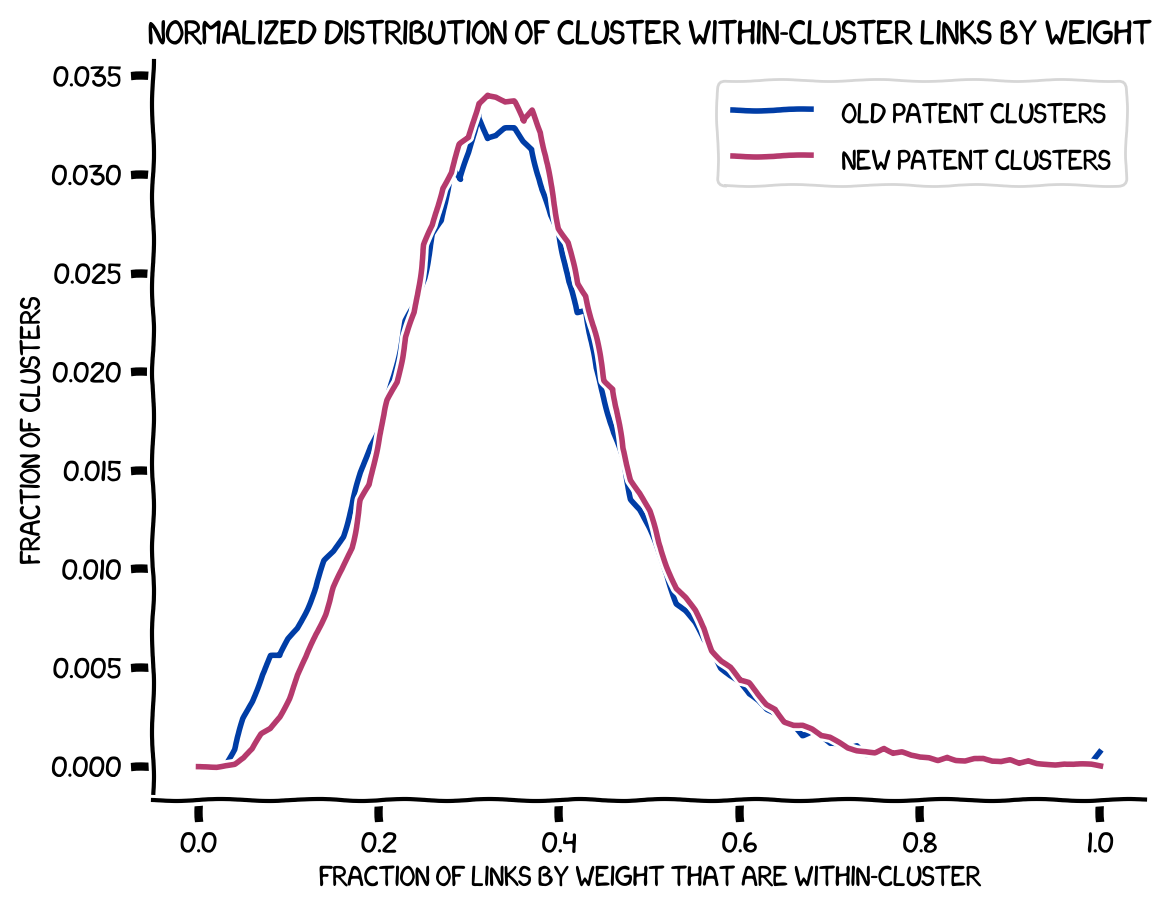

In [27]:
with plt.xkcd():
    plt.figure(dpi=200)
    ax = plt.subplot(111)
    ax.spines[['top','right']].set_visible(False)
    plt.plot(cluster_links_fractions_by_weights, old_cluster_links_fractions_counts_by_weights/sum(old_cluster_links_fractions_counts_by_weights),
            c=cset_colors[1], label='Old Patent Clusters')
    plt.plot(cluster_links_fractions_by_weights, new_cluster_links_fractions_counts_by_weights/sum(new_cluster_links_fractions_counts_by_weights),
            c=cset_colors[2], label='New Patent Clusters')
    plt.legend()
    plt.ylabel('Fraction of Clusters')
    plt.xlabel('Fraction of Links By Weight that are Within-Cluster')
    plt.title('Normalized Distribution of Cluster Within-Cluster Links By Weight')
    plt.show()

In [9]:
## loading CLUSTER MODULARITY by text weights alone
cluster_modularity_by_text_weights = []
with open('metric_data/cluster_modularity_comparison_by_text_weights.csv') as csvfile:
    spamreader = csv.reader(csvfile)
    for row in spamreader:
        cluster_modularity_by_text_weights.append(row)
cluster_modularity_by_text_weights = np.array(cluster_modularity_by_text_weights)
cluster_modularity_by_text_weights[cluster_modularity_by_text_weights == ''] = '0'
[modularity_by_text_weights, old_cluster_modularity_by_text_weights, new_cluster_modularity_by_text_weights] = cluster_modularity_by_text_weights.T[:,1:].astype(float)

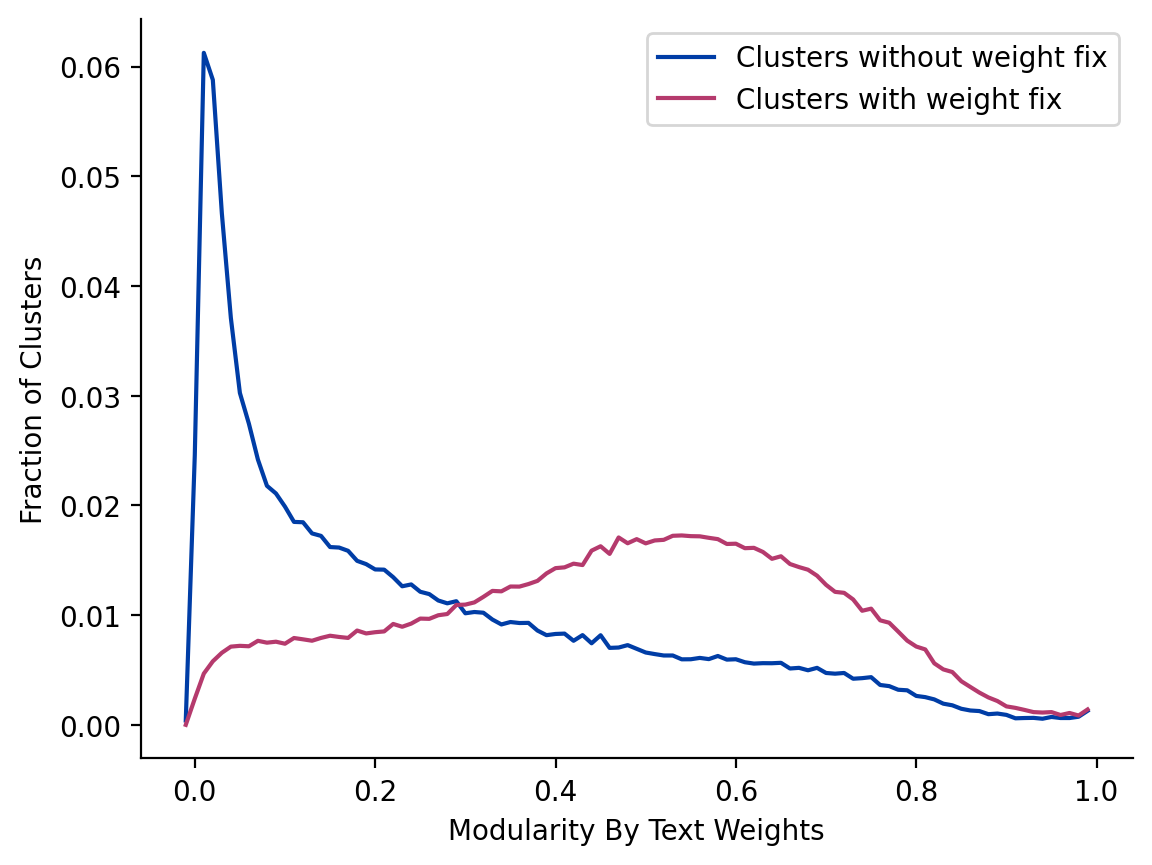

In [11]:
# with plt.xkcd():
plt.figure(dpi=200)
ax = plt.subplot(111)
ax.spines[['top','right']].set_visible(False)
plt.plot(modularity_by_text_weights, old_cluster_modularity_by_text_weights/sum(old_cluster_modularity_by_text_weights),
        c=cset_colors[1],label = 'Clusters without weight fix')
plt.plot(modularity_by_text_weights, new_cluster_modularity_by_text_weights/sum(new_cluster_modularity_by_text_weights),
        c=cset_colors[2],label = 'Clusters with weight fix')
plt.ylabel('Fraction of Clusters')
plt.xlabel('Modularity By Text Weights')
plt.legend()
plt.show()

In [22]:
## loading CLUSTER MODULARITY by cpc weights alone
cluster_modularity_by_cpc_weights = []
with open('metric_data/cluster_modularity_comparison_by_cpc_weights.csv') as csvfile:
    spamreader = csv.reader(csvfile)
    for row in spamreader:
        cluster_modularity_by_cpc_weights.append(row)
cluster_modularity_by_cpc_weights = np.array(cluster_modularity_by_cpc_weights)
cluster_modularity_by_cpc_weights[cluster_modularity_by_cpc_weights == ''] = '0'
[modularity_by_cpc_weights, old_cluster_modularity_by_cpc_weights, new_cluster_modularity_by_cpc_weights] = cluster_modularity_by_cpc_weights.T[:,1:].astype(float)

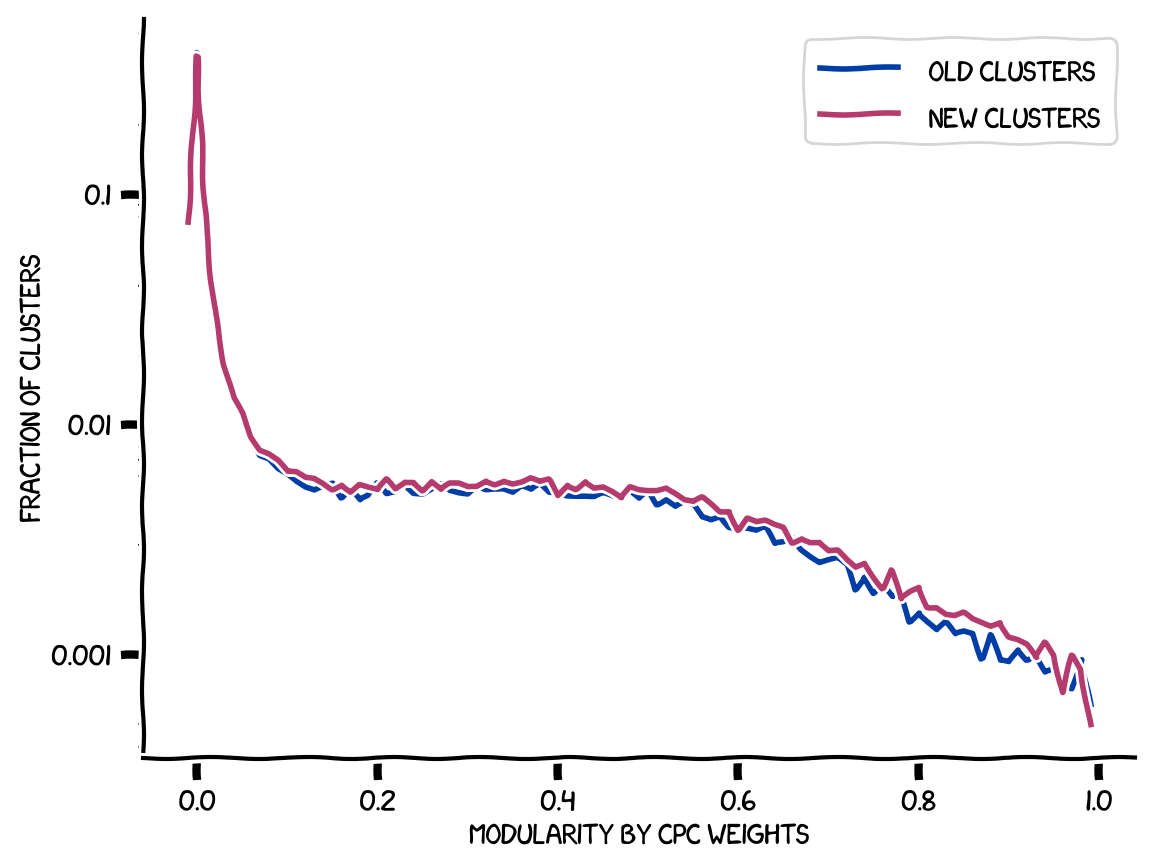

In [23]:
with plt.xkcd():
    plt.figure(dpi=200)
    ax = plt.subplot(111)
    ax.spines[['top','right']].set_visible(False)
    ax.set_yscale('log')
    plt.rcParams['font.sans-serif'] = 'default'
    ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(my_formatter_fun))
    plt.plot(modularity_by_cpc_weights, old_cluster_modularity_by_cpc_weights/sum(old_cluster_modularity_by_cpc_weights),
            c=cset_colors[1],label = 'Old Clusters')
    plt.plot(modularity_by_cpc_weights, new_cluster_modularity_by_cpc_weights/sum(new_cluster_modularity_by_cpc_weights),
            c=cset_colors[2],label = 'New Clusters')
    plt.ylabel('Fraction of Clusters')
    plt.xlabel('Modularity By CPC Weights')
    plt.legend()
    plt.show()

In [13]:
def my_formatter_fun(x, p):
    """ Own formatting function """
    return f'{10**np.log10(x)}'  #  raw string to avoid "\\"

In [89]:
cluster_level_distribution_by_text_weights = []
with open('metric_data/cluster_assignment_level_distribution_comparison_by_text_weights.csv') as csvfile:
    spamreader = csv.reader(csvfile)
    for row in spamreader:
        cluster_level_distribution_by_text_weights.append(row)
cluster_level_distribution_by_text_weights = np.array(cluster_level_distribution_by_text_weights)
cluster_level_distribution_by_text_weights[cluster_level_distribution_by_text_weights == ''] = '0'
[cluster_levels_by_text_weights, old_cluster_level_distribution_by_text_weights,
 new_cluster_level_distribution_by_text_weights] = cluster_level_distribution_by_text_weights.T[:,1:].astype(float)


In [91]:
patent_assignment_level_distribution_by_text_weights = []
with open('metric_data/patent_assignment_level_distribution_comparison_by_text_weights.csv') as csvfile:
    spamreader = csv.reader(csvfile)
    for row in spamreader:
        patent_assignment_level_distribution_by_text_weights.append(row)
patent_assignment_level_distribution_by_text_weights = np.array(patent_assignment_level_distribution_by_text_weights)
[levels_by_text_weights, old_patent_assignment_level_distribution_by_text_weights,
 new_patent_assignment_level_distribution_by_text_weights] = patent_assignment_level_distribution_by_text_weights.T[:,1:].astype(float)

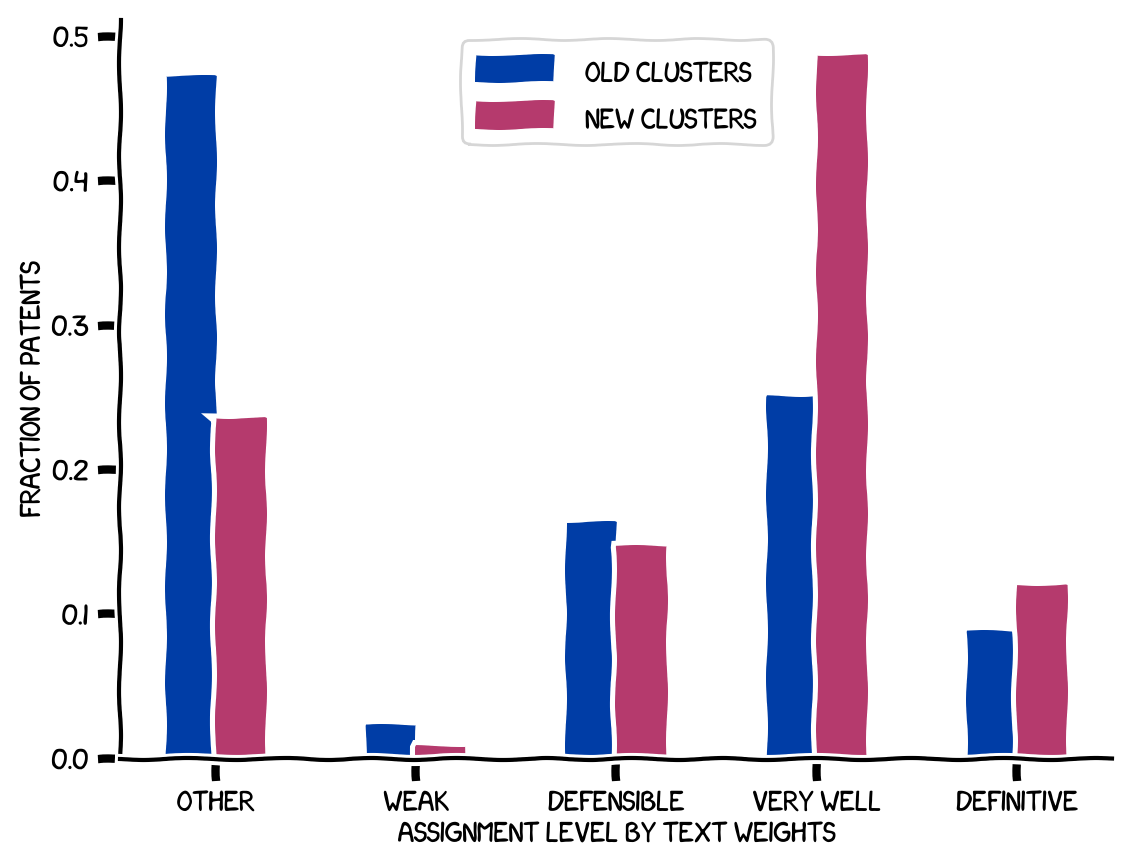

In [92]:
with plt.xkcd():
    plt.figure(dpi=200)
    ax = plt.subplot(111)
    ax.spines[['top','right']].set_visible(False)
    plt.bar(levels-0.25/2, 
            old_patent_assignment_level_distribution_by_text_weights/sum(old_patent_assignment_level_distribution_by_text_weights), 
            width = 0.25,
            color = cset_colors[1], label='Old Clusters')
    plt.bar(levels+0.25/2, 
            new_patent_assignment_level_distribution_by_text_weights/sum(new_patent_assignment_level_distribution_by_text_weights), 
            width = 0.25,
            color = cset_colors[2], label='New Clusters')
    plt.legend()
    plt.xticks([0,1,2,3,4])
    ax.set_xticklabels(['Other','Weak','Defensible','Very Well','Definitive'])
    plt.ylabel('Fraction of Patents')
    plt.xlabel('Assignment Level By Text Weights')
    plt.show()

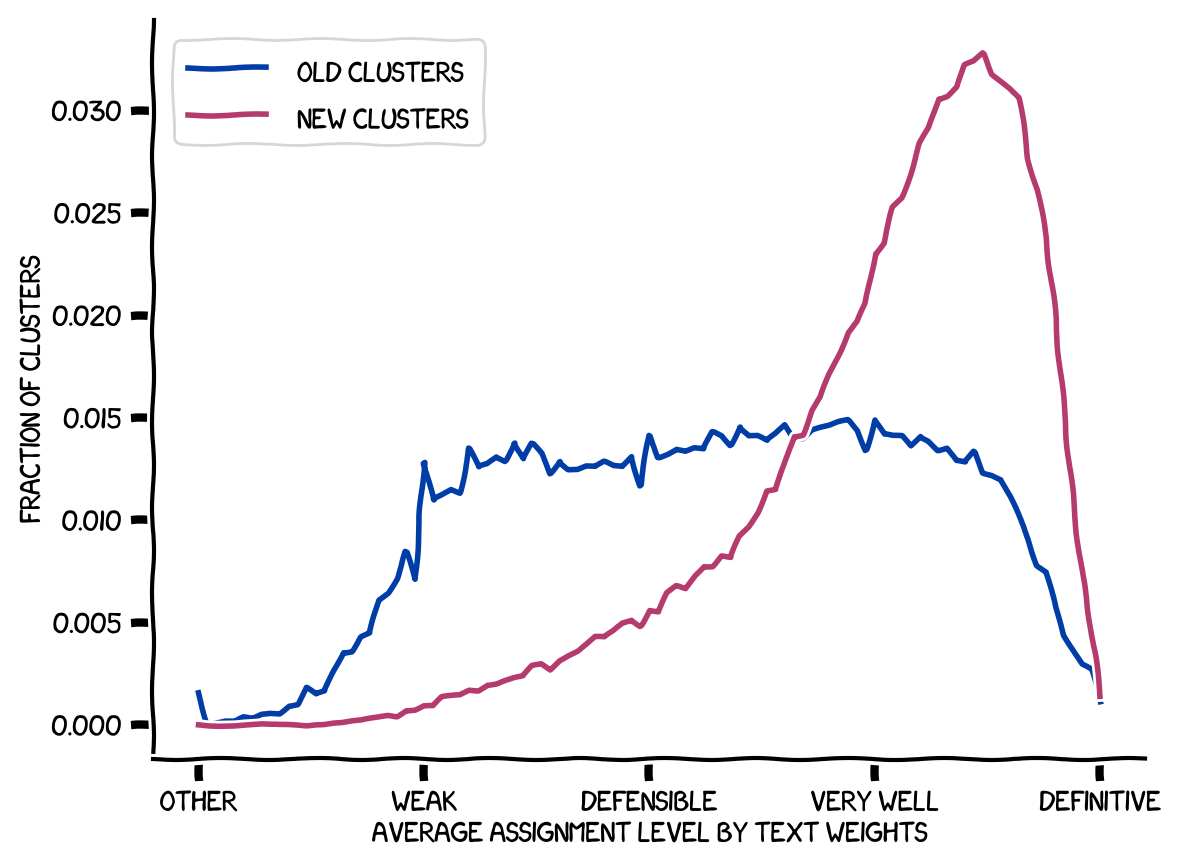

In [93]:
with plt.xkcd():
    plt.figure(dpi=200)
    ax = plt.subplot(111)
    ax.spines[['top','right']].set_visible(False)
    plt.plot(cluster_levels_by_text_weights,
             old_cluster_level_distribution_by_text_weights/sum(old_cluster_level_distribution_by_text_weights), 
             c=cset_colors[1],label='Old Clusters')
    plt.plot(cluster_levels_by_text_weights,
             new_cluster_level_distribution_by_text_weights/sum(new_cluster_level_distribution_by_text_weights), 
             c=cset_colors[2],label='New Clusters')
    plt.ylabel('Fraction of Clusters')
    plt.xlabel('Average Assignment Level By Text Weights')
    plt.xticks([0,1,2,3,4])
    ax.set_xticklabels(['Other','Weak','Defensible','Very Well','Definitive'])
    plt.legend()
    plt.show()

In [94]:
cluster_level_distribution_by_cpc_weights = []
with open('metric_data/cluster_assignment_level_distribution_comparison_by_cpc_weights.csv') as csvfile:
    spamreader = csv.reader(csvfile)
    for row in spamreader:
        cluster_level_distribution_by_cpc_weights.append(row)
cluster_level_distribution_by_cpc_weights = np.array(cluster_level_distribution_by_cpc_weights)
cluster_level_distribution_by_cpc_weights[cluster_level_distribution_by_cpc_weights == ''] = '0'
[cluster_levels_by_cpc_weights, old_cluster_level_distribution_by_cpc_weights,
 new_cluster_level_distribution_by_cpc_weights] = cluster_level_distribution_by_cpc_weights.T[:,1:].astype(float)


In [96]:
patent_assignment_level_distribution_by_cpc_weights = []
with open('metric_data/patent_assignment_level_distribution_comparison_by_cpc_weights.csv') as csvfile:
    spamreader = csv.reader(csvfile)
    for row in spamreader:
        patent_assignment_level_distribution_by_cpc_weights.append(row)
patent_assignment_level_distribution_by_cpc_weights = np.array(patent_assignment_level_distribution_by_cpc_weights)
[levels_by_cpc_weights, old_patent_assignment_level_distribution_by_cpc_weights,
 new_patent_assignment_level_distribution_by_cpc_weights] = patent_assignment_level_distribution_by_cpc_weights.T[:,1:].astype(float)

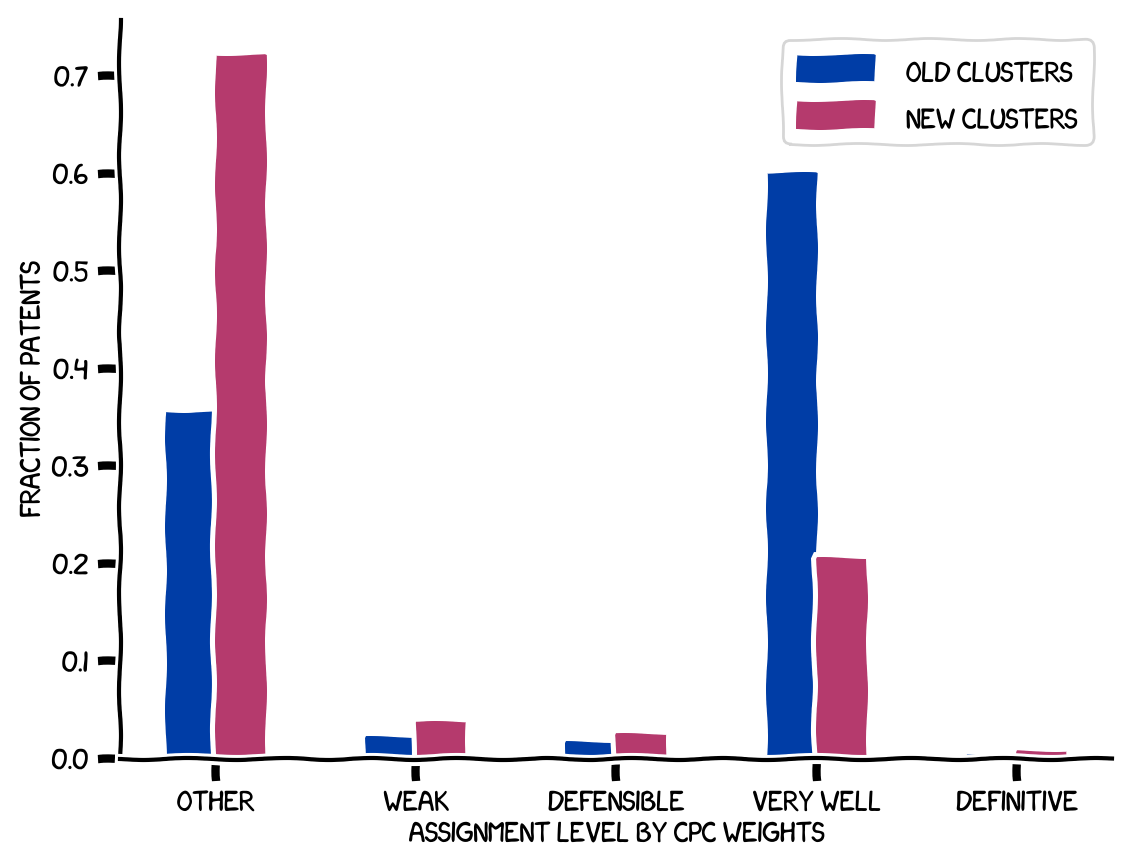

In [97]:
with plt.xkcd():
    plt.figure(dpi=200)
    ax = plt.subplot(111)
    ax.spines[['top','right']].set_visible(False)
    plt.bar(levels-0.25/2, 
            old_patent_assignment_level_distribution_by_cpc_weights/sum(old_patent_assignment_level_distribution_by_cpc_weights), 
            width = 0.25,
            color = cset_colors[1], label='Old Clusters')
    plt.bar(levels+0.25/2, 
            new_patent_assignment_level_distribution_by_cpc_weights/sum(new_patent_assignment_level_distribution_by_cpc_weights), 
            width = 0.25,
            color = cset_colors[2], label='New Clusters')
    plt.legend()
    plt.xticks([0,1,2,3,4])
    ax.set_xticklabels(['Other','Weak','Defensible','Very Well','Definitive'])
    plt.ylabel('Fraction of Patents')
    plt.xlabel('Assignment Level By CPC Weights')
    plt.show()

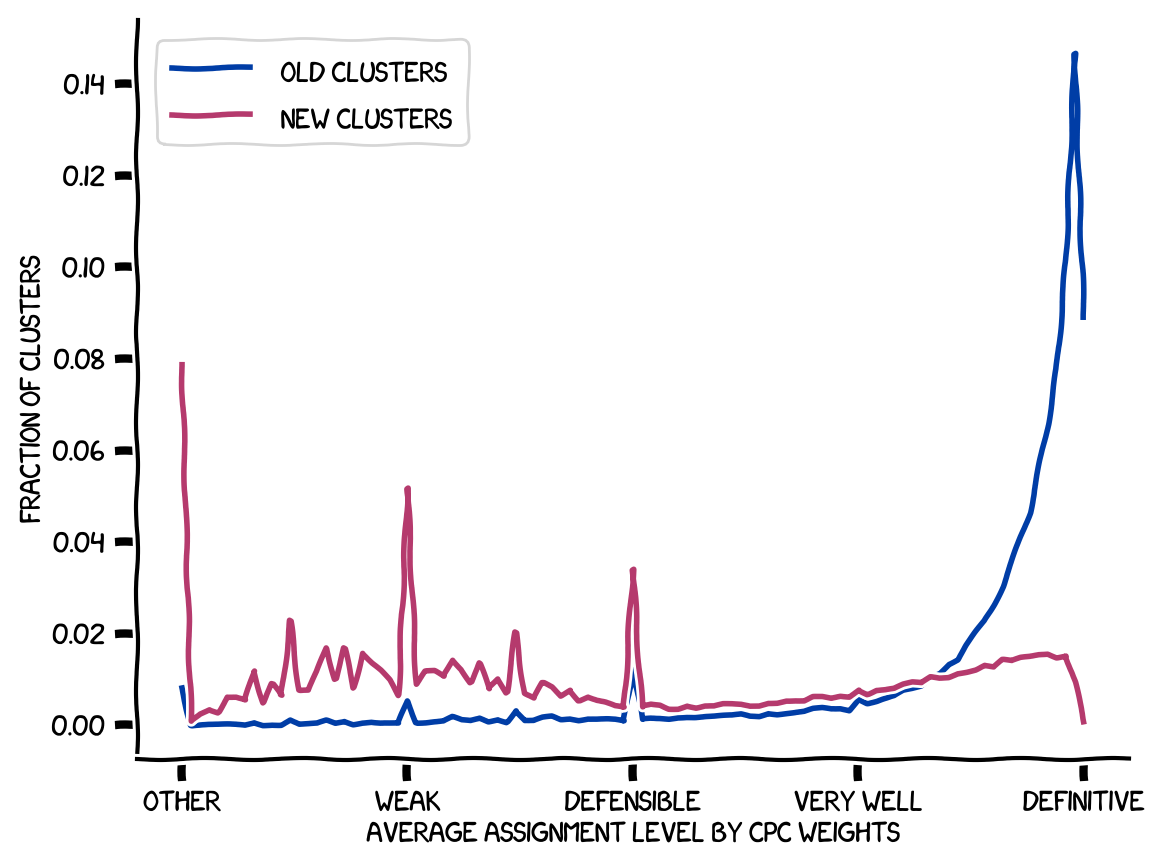

In [98]:
with plt.xkcd():
    plt.figure(dpi=200)
    ax = plt.subplot(111)
    ax.spines[['top','right']].set_visible(False)
    plt.plot(cluster_levels_by_cpc_weights,
             old_cluster_level_distribution_by_cpc_weights/sum(old_cluster_level_distribution_by_cpc_weights), 
             c=cset_colors[1],label='Old Clusters')
    plt.plot(cluster_levels_by_cpc_weights,
             new_cluster_level_distribution_by_cpc_weights/sum(new_cluster_level_distribution_by_cpc_weights), 
             c=cset_colors[2],label='New Clusters')
    plt.ylabel('Fraction of Clusters')
    plt.xlabel('Average Assignment Level By CPC Weights')
    plt.xticks([0,1,2,3,4])
    ax.set_xticklabels(['Other','Weak','Defensible','Very Well','Definitive'])
    plt.legend()
    plt.show()

In [28]:
cluster_links_fractions_by_text_weights = []
with open('metric_data/cluster_links_fractions_comparison_by_text_weights.csv') as csvfile:
    spamreader = csv.reader(csvfile)
    for row in spamreader:
        cluster_links_fractions_by_text_weights.append(row)
cluster_links_fractions_by_text_weights = np.array(cluster_links_fractions_by_text_weights)
cluster_links_fractions_by_text_weights[cluster_links_fractions_by_text_weights == ''] = '0'
[cluster_links_fractions_by_text_weights, old_cluster_links_fractions_counts_by_text_weights,
new_cluster_links_fractions_counts_by_text_weights] = cluster_links_fractions_by_text_weights.T[:,1:].astype(float)

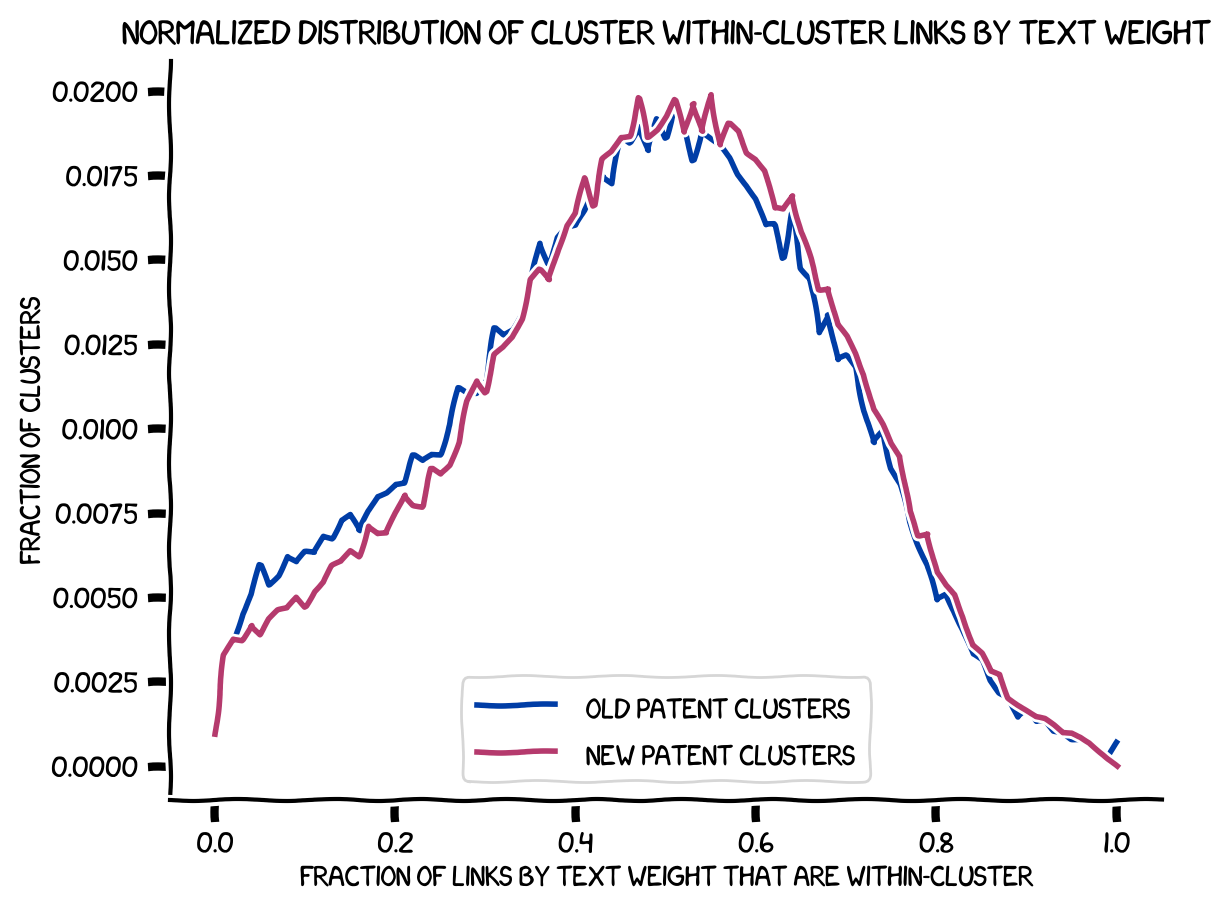

In [29]:
with plt.xkcd():
    plt.figure(dpi=200)
    ax = plt.subplot(111)
    ax.spines[['top','right']].set_visible(False)
    plt.plot(cluster_links_fractions_by_text_weights, old_cluster_links_fractions_counts_by_text_weights/sum(old_cluster_links_fractions_counts_by_text_weights),
            c=cset_colors[1], label='Old Patent Clusters')
    plt.plot(cluster_links_fractions_by_text_weights, new_cluster_links_fractions_counts_by_text_weights/sum(new_cluster_links_fractions_counts_by_text_weights),
            c=cset_colors[2], label='New Patent Clusters')
    plt.legend()
    plt.ylabel('Fraction of Clusters')
    plt.xlabel('Fraction of Links By Text Weight that are Within-Cluster')
    plt.title('Normalized Distribution of Cluster Within-Cluster Links By Text Weight')
    plt.show()

In [30]:
cluster_links_fractions_by_cpc_weights = []
with open('metric_data/cluster_links_fractions_comparison_by_cpc_weights.csv') as csvfile:
    spamreader = csv.reader(csvfile)
    for row in spamreader:
        cluster_links_fractions_by_cpc_weights.append(row)
cluster_links_fractions_by_cpc_weights = np.array(cluster_links_fractions_by_cpc_weights)
cluster_links_fractions_by_cpc_weights[cluster_links_fractions_by_cpc_weights == ''] = '0'
[cluster_links_fractions_by_cpc_weights, old_cluster_links_fractions_counts_by_cpc_weights,
new_cluster_links_fractions_counts_by_cpc_weights] = cluster_links_fractions_by_cpc_weights.T[:,1:].astype(float)

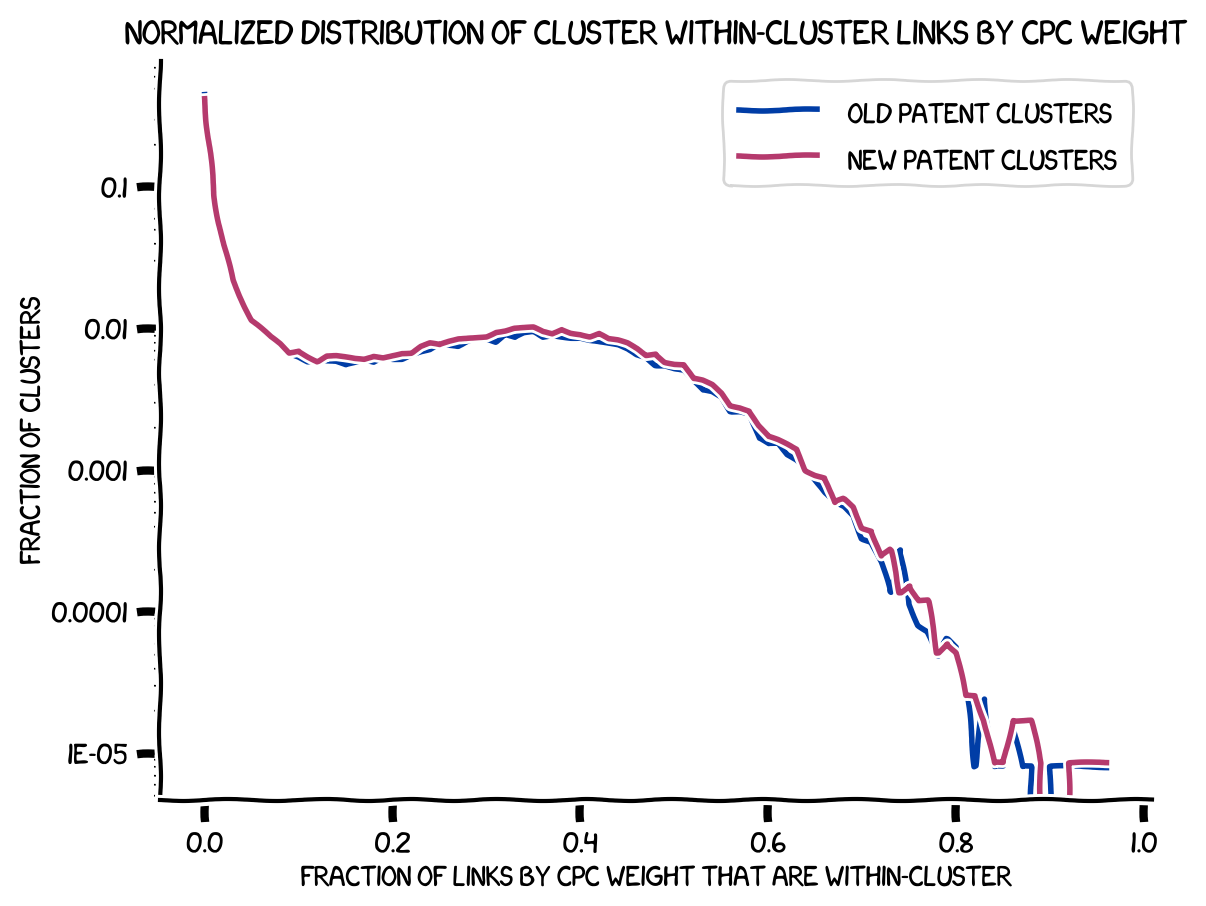

In [31]:
with plt.xkcd():
    plt.figure(dpi=200)
    ax = plt.subplot(111)
    ax.spines[['top','right']].set_visible(False)
    ax.set_yscale('log')
    ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(my_formatter_fun))
    plt.plot(cluster_links_fractions_by_cpc_weights, old_cluster_links_fractions_counts_by_cpc_weights/sum(old_cluster_links_fractions_counts_by_cpc_weights),
            c=cset_colors[1], label='Old Patent Clusters')
    plt.plot(cluster_links_fractions_by_cpc_weights, new_cluster_links_fractions_counts_by_cpc_weights/sum(new_cluster_links_fractions_counts_by_cpc_weights),
            c=cset_colors[2], label='New Patent Clusters')
    plt.legend()
    plt.ylabel('Fraction of Clusters')
    plt.xlabel('Fraction of Links By CPC Weight that are Within-Cluster')
    plt.title('Normalized Distribution of Cluster Within-Cluster Links By CPC Weight')
    plt.show()